# Outlier Filtering for Cool Dwarf Color-Temperature Relationships

This notebook implements outlier detection and filtering for the cross-matched Gaia-LAMOST-LAMOST_vac dataset.

**Approach Summary:**
- Use absolute magnitude colors (intrinsic stellar properties)
- 150 K Teff bins from 2800-4200 K
- **Iterative sigma clipping (astropy) per bin with median centrality**
- **Remove stars flagged in ≥1 colors (strict quality control)**

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.stats import sigma_clip
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define paths using Path for cross-platform compatibility
DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data')
NOTEBOOKS_DIR = Path('notebooks')
RESULTS_DIR = Path('results')

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(exist_ok=True)

## Phase 1: Load and Inspect Dataset

Load the cross-matched dataset and verify its structure.

In [3]:
# Load the cross-matched dataset
input_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac.csv'
df = pd.read_csv(input_path)

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")

# Pre-processing: Standardize to one set of Gaia magnitudes to avoid recomputing colors
print(f"Initial columns: {len(df.columns)}")
# Drop apparent Gaia magnitudes as absolute ones are available and preferred for intrinsic properties
df.drop(columns=['Gmag', 'BPmag', 'RPmag'], inplace=True, errors='ignore')
print(f"Columns after dropping apparent Gaia mags: {len(df.columns)}")

print("\nColumns:", df.columns.tolist())
print(f"\nTeff range: {df['teff'].min():.0f} - {df['teff'].max():.0f} K")
print(f"Teff mean: {df['teff'].mean():.0f} K, median: {df['teff'].median():.0f} K")

Dataset loaded: 48519 rows, 28 columns
Initial columns: 28
Columns after dropping apparent Gaia mags: 25

Columns: ['obsid', 'subclass', 'gaia_source_id', 'distance_gaia_pc', 'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y', 'teff', 'logg', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_BAP', 'A_VAP', 'A_RAP', 'A_GSD', 'A_RSD', 'A_ISD']

Teff range: 3114 - 4138 K
Teff mean: 3690 K, median: 3724 K


In [4]:
# Basic data quality check
print("Missing values summary:")
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

# Filter to reasonable Teff range for cool dwarfs
teff_min, teff_max = 2800, 4200
df = df[(df['teff'] >= teff_min) & (df['teff'] <= teff_max)]
print(f"\nAfter Teff range filtering: {len(df)} stars")

Missing values summary:
Series([], dtype: int64)

After Teff range filtering: 48519 stars


## Phase 2: Create Color Indices

Create color indices from all 21 distinct magnitudes for physics-based intrinsic properties.

In [5]:
# Define ALL 21 distinct magnitudes (after dropping apparent Gaia mags)
# Survey breakdown:
# - Gaia absolute (3): A_GG, A_BP, A_RP
# - Pan-STARRS (5): mag_ps_g, mag_ps_r, mag_ps_i, mag_ps_z, mag_ps_y
# - 2MASS (3): A_J, A_H, A_KS
# - WISE (2): A_W1, A_W2
# - APASS (3): A_BAP, A_VAP, A_RAP
# - SDSS (5): A_GSD, A_RSD, A_ISD (note: only 3 SDSS mags in this dataset)
# Total: 3+5+3+2+3+3 = 19 distinct magnitude bands used

all_magnitudes = [
    # Gaia absolute magnitudes
    'A_GG', 'A_BP', 'A_RP',
    # Pan-STARRS
    'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y',
    # 2MASS
    'A_J', 'A_H', 'A_KS',
    # WISE
    'A_W1', 'A_W2',
    # APASS
    'A_BAP', 'A_VAP', 'A_RAP',
    # SDSS
    'A_GSD', 'A_RSD', 'A_ISD'
]

# Check which magnitudes are actually in the dataframe
available_mags = [m for m in all_magnitudes if m in df.columns]
missing_mags = [m for m in all_magnitudes if m not in df.columns]

print(f"Expected magnitudes: {len(all_magnitudes)}")
print(f"Available magnitudes: {len(available_mags)}")
if missing_mags:
    print(f"Missing magnitudes: {missing_mags}")
else:
    print("All expected magnitudes are present!")

# Define color combinations covering all available magnitudes
color_combinations = {
    # Gaia (3 mags -> 2 colors to form connected chain)
    'COLOR_GAIA_BP_RP': ('A_BP', 'A_RP'),
    'COLOR_GAIA_G_BP': ('A_GG', 'A_BP'),
    
    # Pan-STARRS (5 mags -> 4 colors to form connected chain)
    'COLOR_PS_G_R': ('mag_ps_g', 'mag_ps_r'),
    'COLOR_PS_R_I': ('mag_ps_r', 'mag_ps_i'),
    'COLOR_PS_I_Z': ('mag_ps_i', 'mag_ps_z'),
    'COLOR_PS_Z_Y': ('mag_ps_z', 'mag_ps_y'),
    
    # 2MASS (3 mags -> 2 colors to form connected chain)
    'COLOR_2MASS_J_H': ('A_J', 'A_H'),
    'COLOR_2MASS_H_KS': ('A_H', 'A_KS'),
    
    # WISE (2 mags -> 1 color)
    'COLOR_WISE_W1_W2': ('A_W1', 'A_W2'),
    
    # APASS (3 mags -> 2 colors to form connected chain)
    'COLOR_APASS_B_V': ('A_BAP', 'A_VAP'),
    'COLOR_APASS_V_R': ('A_VAP', 'A_RAP'),
    
    # SDSS (3 mags -> 2 colors to form connected chain)
    'COLOR_SDSS_G_R': ('A_GSD', 'A_RSD'),
    'COLOR_SDSS_R_I': ('A_RSD', 'A_ISD'),
    
    # Cross-survey connections to ensure all mags are linked
    'COLOR_X_GAIA_PS': ('A_GG', 'mag_ps_g'),
    'COLOR_X_PS_2MASS': ('mag_ps_y', 'A_J'),
    'COLOR_X_2MASS_WISE': ('A_KS', 'A_W1'),
    'COLOR_X_APASS_SDSS': ('A_BAP', 'A_GSD'),
    'COLOR_X_SDSS_GAIA': ('A_ISD', 'A_RP')
}

# Verify all magnitudes are used in at least one color
mags_used = set()
for color_name, (mag1, mag2) in color_combinations.items():
    mags_used.add(mag1)
    mags_used.add(mag2)

mags_not_used = set(available_mags) - mags_used
if mags_not_used:
    print(f"\nWARNING: These magnitudes are NOT used in any color: {mags_not_used}")
else:
    print(f"\n✓ All {len(mags_used)} available magnitudes are used in color combinations")

# Create color columns
for color_name, (mag1, mag2) in color_combinations.items():
    if mag1 in df.columns and mag2 in df.columns:
        df[color_name] = df[mag1] - df[mag2]
    else:
        print(f"WARNING: Cannot create {color_name}, missing column(s)")

print(f"\nCreated {len(color_combinations)} color indices:")
for name, (m1, m2) in color_combinations.items():
    print(f"  {name}: {m1} - {m2}")

Expected magnitudes: 19
Available magnitudes: 19
All expected magnitudes are present!

✓ All 19 available magnitudes are used in color combinations

Created 18 color indices:
  COLOR_GAIA_BP_RP: A_BP - A_RP
  COLOR_GAIA_G_BP: A_GG - A_BP
  COLOR_PS_G_R: mag_ps_g - mag_ps_r
  COLOR_PS_R_I: mag_ps_r - mag_ps_i
  COLOR_PS_I_Z: mag_ps_i - mag_ps_z
  COLOR_PS_Z_Y: mag_ps_z - mag_ps_y
  COLOR_2MASS_J_H: A_J - A_H
  COLOR_2MASS_H_KS: A_H - A_KS
  COLOR_WISE_W1_W2: A_W1 - A_W2
  COLOR_APASS_B_V: A_BAP - A_VAP
  COLOR_APASS_V_R: A_VAP - A_RAP
  COLOR_SDSS_G_R: A_GSD - A_RSD
  COLOR_SDSS_R_I: A_RSD - A_ISD
  COLOR_X_GAIA_PS: A_GG - mag_ps_g
  COLOR_X_PS_2MASS: mag_ps_y - A_J
  COLOR_X_2MASS_WISE: A_KS - A_W1
  COLOR_X_APASS_SDSS: A_BAP - A_GSD
  COLOR_X_SDSS_GAIA: A_ISD - A_RP


## Phase 3: Teff Binning

Define Teff bins with fixed width (150 K) ensuring adequate samples per bin.

Teff bin statistics:
              teff                           
             count      min      max     mean
teff_bin                                     
2800-2950 K      0      NaN      NaN      NaN
2950-3100 K      0      NaN      NaN      NaN
3100-3250 K    750  3114.00  3249.90  3205.65
3250-3400 K   4413  3250.12  3399.96  3340.82
3400-3550 K   6704  3400.01  3549.98  3481.34
3550-3700 K   9875  3550.00  3699.98  3636.81
3700-3850 K  15269  3700.00  3849.99  3775.38
3850-4000 K  11194  3850.00  3999.96  3906.90
4000-4150 K    314  4000.02  4138.39  4027.61
4150-4300 K      0      NaN      NaN      NaN


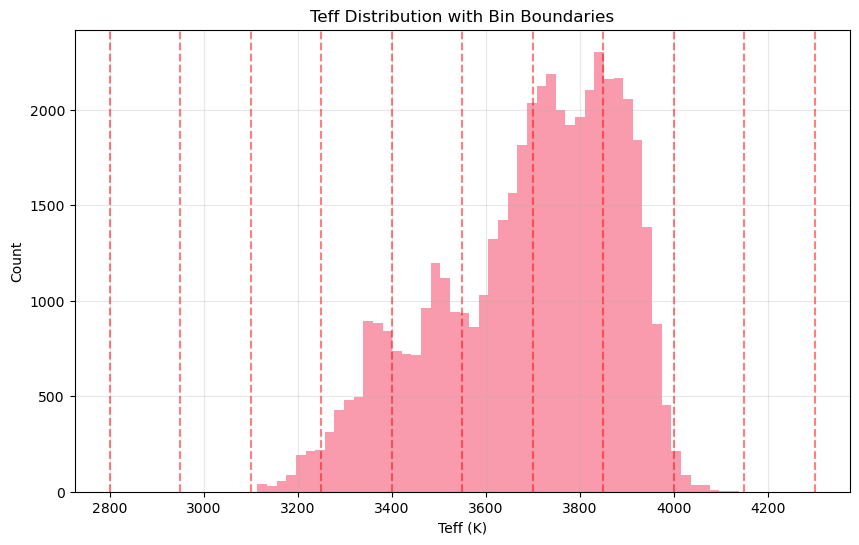

In [ ]:
# Create Teff bins
bin_width = 150  # K
teff_bins = np.arange(2800, 4200 + bin_width, bin_width)

# Add bin column to dataframe
df['teff_bin'] = pd.cut(df['teff'], teff_bins, right=False, 
                        labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' 
                               for i in range(len(teff_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('teff_bin').agg({
    'teff': ['count', 'min', 'max', 'mean']
}).round(2)

print("Teff bin statistics:")
print(bin_stats)

# Visualize Teff distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
df['teff'].plot.hist(bins=50, ax=ax, alpha=0.7)

# Add vertical lines for bin boundaries
for teff_boundary in teff_bins:
    ax.axvline(teff_boundary, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('Teff (K)')
ax.set_ylabel('Count')
ax.set_title('Teff Distribution with Bin Boundaries')
ax.grid(True, alpha=0.3)
#plt.savefig(RESULTS_DIR / 'teff_distribution_bins.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4: Outlier Detection (Iterative Sigma Clipping)

Apply iterative sigma clipping using `astropy.stats.sigma_clip` per Teff bin for each color index.

In [7]:
def detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None):
    """
    Use astropy's iterative sigma clipping to detect outliers.
    Returns a boolean series where True indicates an outlier.
    """
    values = df_bin[color_name].dropna()
    if len(values) < 10:
        return pd.Series(False, index=df_bin.index)
    
    # Apply sigma clipping
    clipped_data = sigma_clip(values, sigma=sigma, maxiters=maxiters, cenfunc='median', stdfunc='std')
    
    # Identify outliers (values that were clipped/masked)
    # clipped_data is a masked array where masked=True means outlier
    outlier_mask = clipped_data.mask
    
    return pd.Series(outlier_mask, index=values.index)

# Create outlier flags for each color and bin
outlier_columns = []

for color_name in color_combinations.keys():
    outlier_col_name = f'{color_name}_outlier'
    outlier_columns.append(outlier_col_name)
    df[outlier_col_name] = False 
    
    for bin_name, df_bin in df.groupby('teff_bin'):
        outlier_mask = detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None)
        df.loc[outlier_mask.index, outlier_col_name] = outlier_mask

print(f"Created {len(outlier_columns)} outlier flag columns using iterative sigma clipping")

Created 18 outlier flag columns using iterative sigma clipping


In [8]:
# Convergence Diagnostics and Detailed Statistics
print("=" * 80)
print("=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===")
print("=" * 80)

convergence_stats = {}

for color_name in color_combinations.keys():
    convergence_stats[color_name] = {}
    
    for bin_name, df_bin in df.groupby('teff_bin'):
        values = df_bin[color_name].dropna()
        if len(values) >= 10:
            # Run sigma clipping with 5 iterations
            clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, 
                                   cenfunc='median', stdfunc='std')
            # Run sigma clipping until convergence (maxiters=None)
            clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, 
                                       cenfunc='median', stdfunc='std')
            
            convergence_stats[color_name][bin_name] = {
                'original_N': len(values),
                'after_5_iters_N': int((~clipped_5.mask).sum()),
                'final_N': int((~clipped_final.mask).sum()),
                'removed_5_iters': int(clipped_5.mask.sum()),
                'removed_final': int(clipped_final.mask.sum()),
                'original_median': float(np.median(values)),
                'original_std': float(np.std(values)),
                'final_median': float(np.median(values[~clipped_final.mask])),
                'final_std': float(np.std(values[~clipped_final.mask]))
            }

# Print detailed convergence statistics per color
print("\n=== Per-Color Convergence Summary ===\n")
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    
    print(f"\n{color_name}:")
    print(f"  Total stars: {total_original}")
    print(f"  Removed after 5 iters: {total_removed_5} ({100*total_removed_5/total_original:.3f}%)")
    print(f"  Removed (converged):   {total_removed_final} ({100*total_removed_final/total_original:.3f}%)")
    print(f"  Difference (5 vs converged): {total_removed_final - total_removed_5}")
    
    print(f"  Per-bin breakdown:")
    for bin_name, stats in convergence_stats[color_name].items():
        print(f"    {bin_name}: {stats['original_N']:5d} -> {stats['final_N']:5d} "
              f"(removed: {stats['removed_final']:4d}, "
              f"median: {stats['original_median']:.3f} -> {stats['final_median']:.3f}, "
              f"std: {stats['original_std']:.3f} -> {stats['final_std']:.3f})")

# Create strict consensus outlier flag: outlier if flagged in ANY color (>=1)
df['outlier_consensus'] = df[outlier_columns].any(axis=1)

total_stars = len(df)
outlier_stars = df['outlier_consensus'].sum()
clean_stars = total_stars - outlier_stars

print("\n" + "=" * 80)
print("=== FINAL OUTLIER SUMMARY ===")
print("=" * 80)
print(f"\nTotal stars: {total_stars}")
print(f"Outliers (flagged in ≥1 colors): {outlier_stars} ({100*outlier_stars/total_stars:.2f}%)")
print(f"Clean stars: {clean_stars} ({100*clean_stars/total_stars:.2f}%)")

print("\nSurvival statistics by Teff bin:")
bin_survival = df.groupby('teff_bin').agg({
    'obsid': 'count',
    'outlier_consensus': 'sum'
})
bin_survival.columns = ['total', 'outliers']
bin_survival['survival_rate'] = 100 * (1 - bin_survival['outliers']/bin_survival['total'])
print(bin_survival.round(2))

=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===

=== Per-Color Convergence Summary ===


COLOR_GAIA_BP_RP:
  Total stars: 48519
  Removed after 5 iters: 1636 (3.372%)
  Removed (converged):   1749 (3.605%)
  Difference (5 vs converged): 113
  Per-bin breakdown:
    3100-3250 K:   750 ->   714 (removed:   36, median: 4.117 -> 4.140, std: 13.690 -> 0.713)
    3250-3400 K:  4413 ->  4255 (removed:  158, median: 3.684 -> 3.695, std: 20.222 -> 0.681)
    3400-3550 K:  6704 ->  6508 (removed:  196, median: 3.233 -> 3.241, std: 85.956 -> 0.712)
    3550-3700 K:  9875 ->  9526 (removed:  349, median: 2.592 -> 2.597, std: 35.043 -> 0.668)
    3700-3850 K: 15269 -> 14777 (removed:  492, median: 2.132 -> 2.133, std: 3.871 -> 0.608)
    3850-4000 K: 11194 -> 10701 (removed:  493, median: 1.872 -> 1.876, std: 356.675 -> 0.548)
    4000-4150 K:   314 ->   289 (removed:   25, median: 1.716 -> 1.719, std: 53.328 -> 0.529)

COLOR_GAIA_G_BP:
  Total stars: 48519
  Removed after 5 iters: 1731 (3.5

## Phase 5: Diagnostic Plots (Comparison of Filtering Iterations)

Compare the sigma clipping effect at different iteration stages:
1. **Initial**: Raw data before any sigma clipping
2. **After 5 iterations**: Standard astropy default
3. **Final (Converged)**: After maxiters=None (iterate until no more outliers)

This visualization helps verify the method is working correctly and shows how much additional cleaning the full convergence provides.

=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===


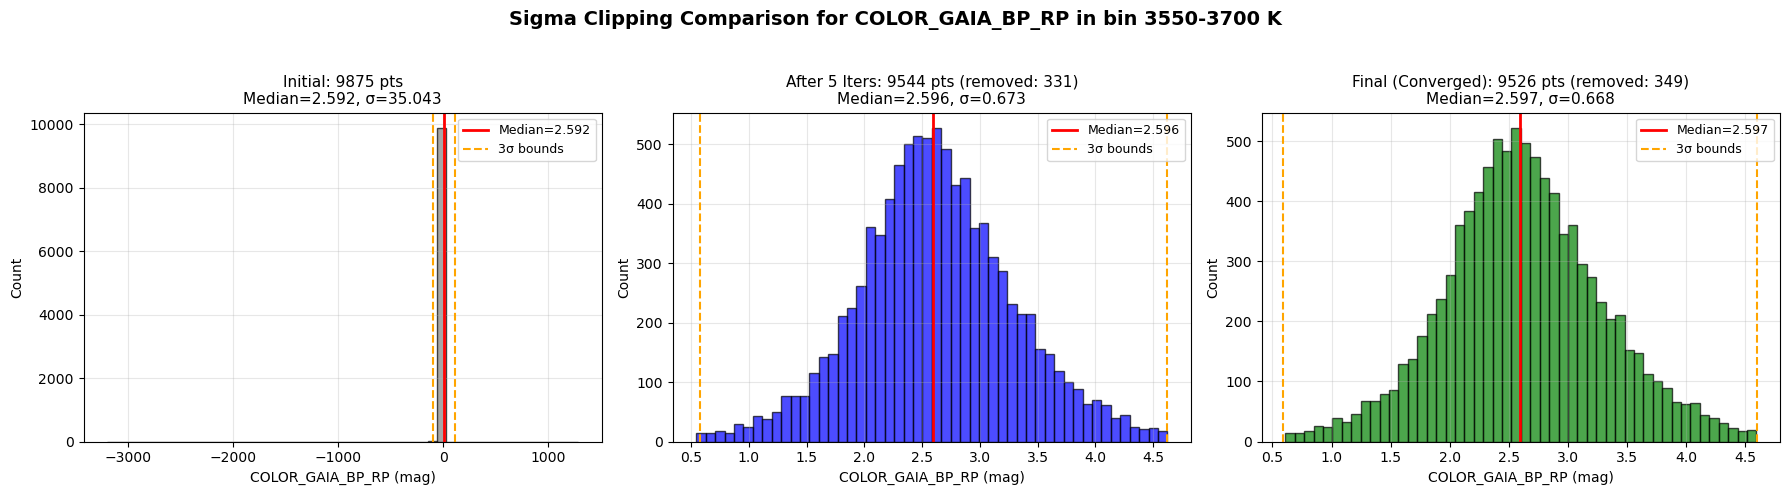


COLOR_GAIA_BP_RP in 3550-3700 K:
  Initial:      9875 pts, median=2.5919, std=35.0426
  After 5 its:  9544 pts, median=2.5963, std=0.6731, removed=331
  Final:        9526 pts, median=2.5972, std=0.6679, removed=349
  Difference (5 iters vs converged): 18 additional pts removed


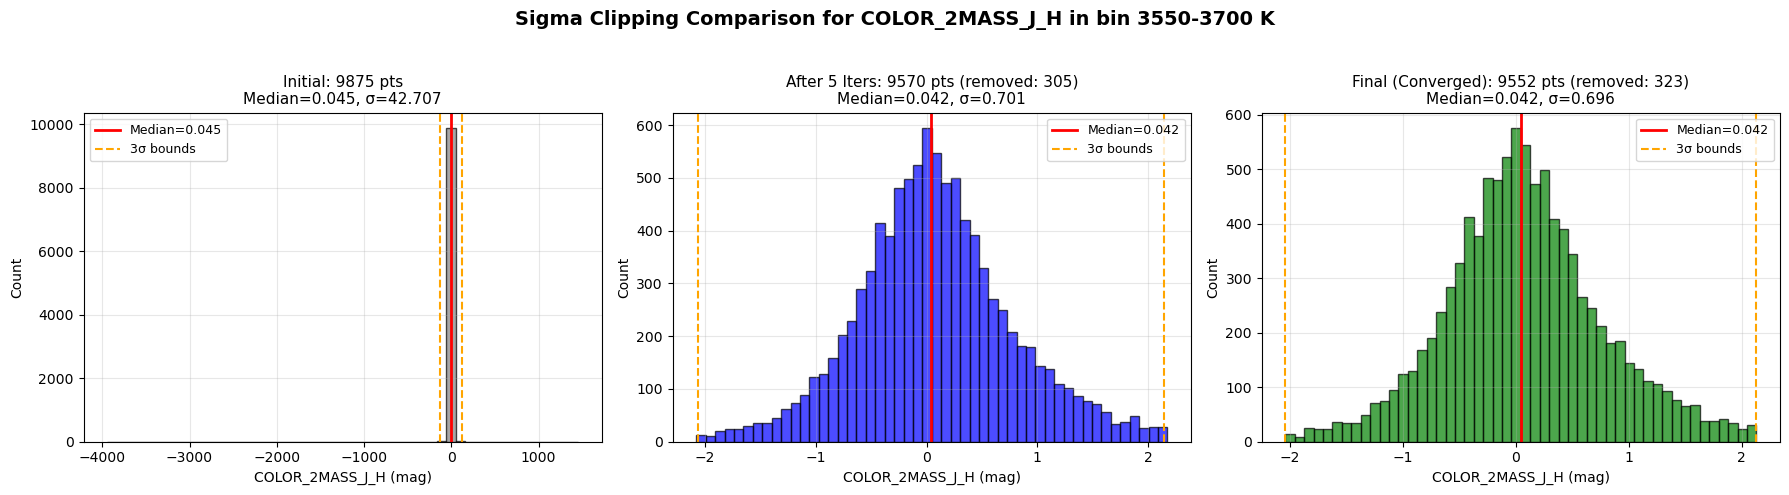


COLOR_2MASS_J_H in 3550-3700 K:
  Initial:      9875 pts, median=0.0451, std=42.7072
  After 5 its:  9570 pts, median=0.0422, std=0.7014, removed=305
  Final:        9552 pts, median=0.0419, std=0.6961, removed=323
  Difference (5 iters vs converged): 18 additional pts removed


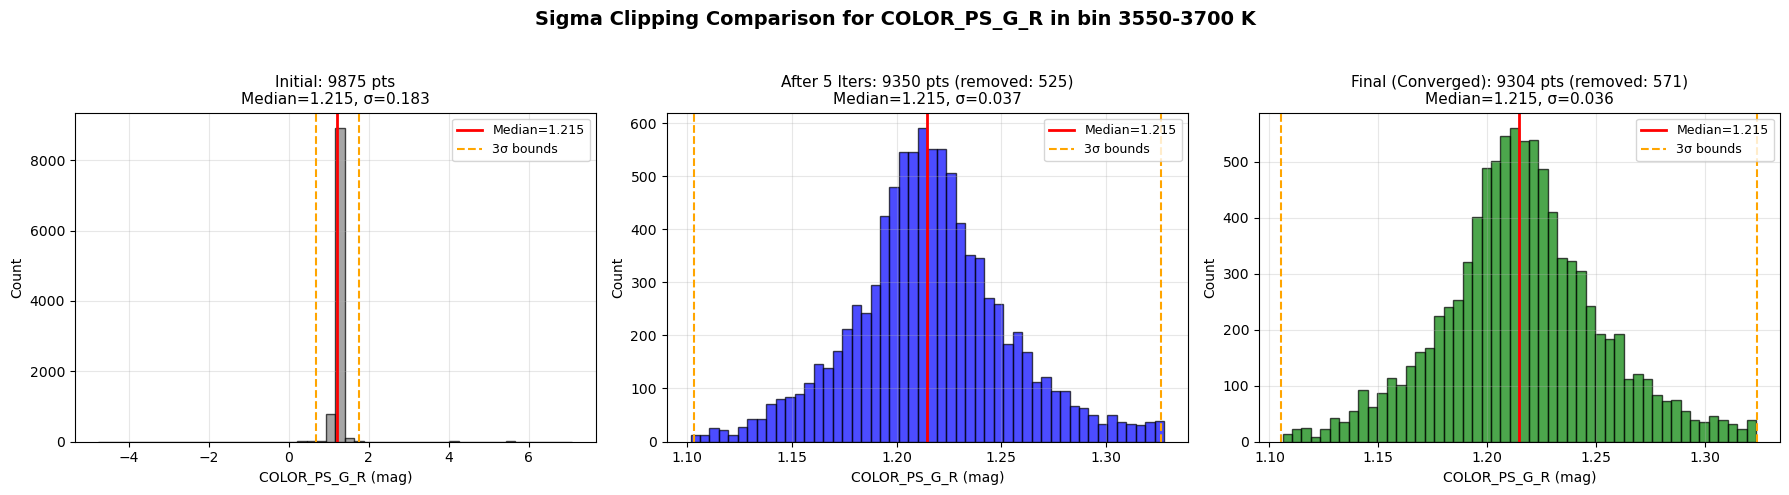


COLOR_PS_G_R in 3550-3700 K:
  Initial:      9875 pts, median=1.2153, std=0.1830
  After 5 its:  9350 pts, median=1.2147, std=0.0372, removed=525
  Final:        9304 pts, median=1.2146, std=0.0364, removed=571
  Difference (5 iters vs converged): 46 additional pts removed


In [ ]:
# Comparison visualization: Initial vs 5 iterations vs Final (converged)
def compare_clipping_iterations(df, color_name, bin_name):
    """
    Compare the effect of sigma clipping at different iteration stages.
    Shows: (1) Initial, (2) After 5 iterations, (3) Final converged result.
    """
    df_bin = df[df['teff_bin'] == bin_name]
    values = df_bin[color_name].dropna()
    
    if len(values) < 10:
        print(f"Not enough data points in bin {bin_name} for {color_name}")
        return
    
    # 1. Initial (no clipping)
    initial_median = np.median(values)
    initial_std = np.std(values)
    
    # 2. After 5 iterations
    clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, cenfunc='median', stdfunc='std')
    values_5 = values[~clipped_5.mask]
    median_5 = np.median(values_5)
    std_5 = np.std(values_5)
    
    # 3. Final (None iterations = until convergence)
    clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, cenfunc='median', stdfunc='std')
    values_final = values[~clipped_final.mask]
    median_final = np.median(values_final)
    std_final = np.std(values_final)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Initial
    ax1 = axes[0]
    ax1.hist(values, bins=50, color='gray', alpha=0.7, edgecolor='black')
    ax1.axvline(initial_median, color='red', linewidth=2, label=f'Median={initial_median:.3f}')
    ax1.axvline(initial_median - 3*initial_std, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax1.axvline(initial_median + 3*initial_std, color='orange', linestyle='--', linewidth=1.5)
    ax1.set_title(f'Initial: {len(values)} pts\nMedian={initial_median:.3f}, σ={initial_std:.3f}', fontsize=11)
    ax1.set_xlabel(f'{color_name} (mag)')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: After 5 iterations
    ax2 = axes[1]
    ax2.hist(values_5, bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax2.axvline(median_5, color='red', linewidth=2, label=f'Median={median_5:.3f}')
    ax2.axvline(median_5 - 3*std_5, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax2.axvline(median_5 + 3*std_5, color='orange', linestyle='--', linewidth=1.5)
    removed_5 = len(values) - len(values_5)
    ax2.set_title(f'After 5 Iters: {len(values_5)} pts (removed: {removed_5})\nMedian={median_5:.3f}, σ={std_5:.3f}', fontsize=11)
    ax2.set_xlabel(f'{color_name} (mag)')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Final (converged)
    ax3 = axes[2]
    ax3.hist(values_final, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax3.axvline(median_final, color='red', linewidth=2, label=f'Median={median_final:.3f}')
    ax3.axvline(median_final - 3*std_final, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax3.axvline(median_final + 3*std_final, color='orange', linestyle='--', linewidth=1.5)
    removed_final = len(values) - len(values_final)
    ax3.set_title(f'Final (Converged): {len(values_final)} pts (removed: {removed_final})\nMedian={median_final:.3f}, σ={std_final:.3f}', fontsize=11)
    ax3.set_xlabel(f'{color_name} (mag)')
    ax3.set_ylabel('Count')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sigma Clipping Comparison for {color_name} in bin {bin_name}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.savefig(RESULTS_DIR / f'clipping_comparison_{color_name}_{bin_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{color_name} in {bin_name}:")
    print(f"  Initial:     {len(values):5d} pts, median={initial_median:.4f}, std={initial_std:.4f}")
    print(f"  After 5 its: {len(values_5):5d} pts, median={median_5:.4f}, std={std_5:.4f}, removed={removed_5}")
    print(f"  Final:       {len(values_final):5d} pts, median={median_final:.4f}, std={std_final:.4f}, removed={removed_final}")
    print(f"  Difference (5 iters vs converged): {removed_final - removed_5} additional pts removed")

# Show comparison for representative colors and bins
print("=" * 80)
print("=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===")
print("=" * 80)

# Get middle bin for representative comparison
teff_bins_available = sorted(df['teff_bin'].dropna().unique())
middle_bin_idx = len(teff_bins_available) // 2
representative_bin = teff_bins_available[middle_bin_idx]

# Show comparisons for a few representative colors
representative_colors = ['COLOR_GAIA_BP_RP', 'COLOR_2MASS_J_H', 'COLOR_PS_G_R']
for color in representative_colors:
    if color in color_combinations:
        compare_clipping_iterations(df, color, representative_bin)

In [10]:
# Summary table: Compare 5 iterations vs converged across ALL colors
print("\n" + "=" * 80)
print("=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===")
print("=" * 80)

summary_data = []
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    diff = total_removed_final - total_removed_5
    
    summary_data.append({
        'Color': color_name,
        'Total': total_original,
        'Removed (5 iters)': total_removed_5,
        'Removed (converged)': total_removed_final,
        'Extra removed': diff,
        '% Removed (5 iters)': f"{100*total_removed_5/total_original:.2f}%",
        '% Removed (converged)': f"{100*total_removed_final/total_original:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Overall summary
total_original_all = sum(s['Total'] for s in summary_data)
total_removed_5_all = sum(s['Removed (5 iters)'] for s in summary_data)
total_removed_final_all = sum(s['Removed (converged)'] for s in summary_data)

print(f"\n--- Overall (summed across all colors) ---")
print(f"Total data points (all colors combined): {total_original_all}")
print(f"Total removed after 5 iterations: {total_removed_5_all}")
print(f"Total removed after convergence: {total_removed_final_all}")
print(f"Additional removed by convergence: {total_removed_final_all - total_removed_5_all}")


=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===
             Color  Total  Removed (5 iters)  Removed (converged)  Extra removed % Removed (5 iters) % Removed (converged)
  COLOR_GAIA_BP_RP  48519               1636                 1749            113               3.37%                 3.60%
   COLOR_GAIA_G_BP  48519               1731                 1863            132               3.57%                 3.84%
      COLOR_PS_G_R  48519               2842                 3030            188               5.86%                 6.24%
      COLOR_PS_R_I  48519               2539                 2708            169               5.23%                 5.58%
      COLOR_PS_I_Z  48519               2853                 3006            153               5.88%                 6.20%
      COLOR_PS_Z_Y  48519               3684                 3940            256               7.59%                 8.12%
   COLOR_2MASS_J_H  48519               1619                 1722          

## Phase 6: Save Filtered Dataset

Create clean dataset and save.

In [11]:
df_clean = df[~df['outlier_consensus']].copy()
df_outliers = df[df['outlier_consensus']].copy()

cols_to_drop = outlier_columns + ['teff_bin', 'outlier_consensus']
df_clean_out = df_clean.drop(columns=cols_to_drop, errors='ignore')

clean_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_clean.csv'
df_clean_out.to_csv(clean_path, index=False)

print(f"Clean dataset saved: {len(df_clean_out)} stars -> {clean_path}")

Clean dataset saved: 35267 stars -> C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_gaia_LAMOST_LAMOSTvac_clean.csv


## Phase 7: Sanity Check For Cleaned Dataset

Using the cleaned dataset (after outlier removal), generate comprehensive visualization for:
1. Color distributions plots (ALL colors)
2. ALL color vs Teff plots without outliers
3. Bin-wise plots for ALL colors (detailed distributions per Teff bin)

In [12]:
# Load the cleaned dataset for comprehensive visualization
clean_data_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_clean.csv'
df_clean_viz = pd.read_csv(clean_data_path)

print(f"Cleaned dataset loaded for viz: {len(df_clean_viz)} stars")

# Recompute colors for the viz dataframe
for color_name, (mag1, mag2) in color_combinations.items():
    df_clean_viz[color_name] = df_clean_viz[mag1] - df_clean_viz[mag2]

df_clean_viz['teff_bin'] = pd.cut(
    df_clean_viz['teff'], teff_bins, right=False,
    labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' for i in range(len(teff_bins)-1)]
)

Cleaned dataset loaded for viz: 35267 stars


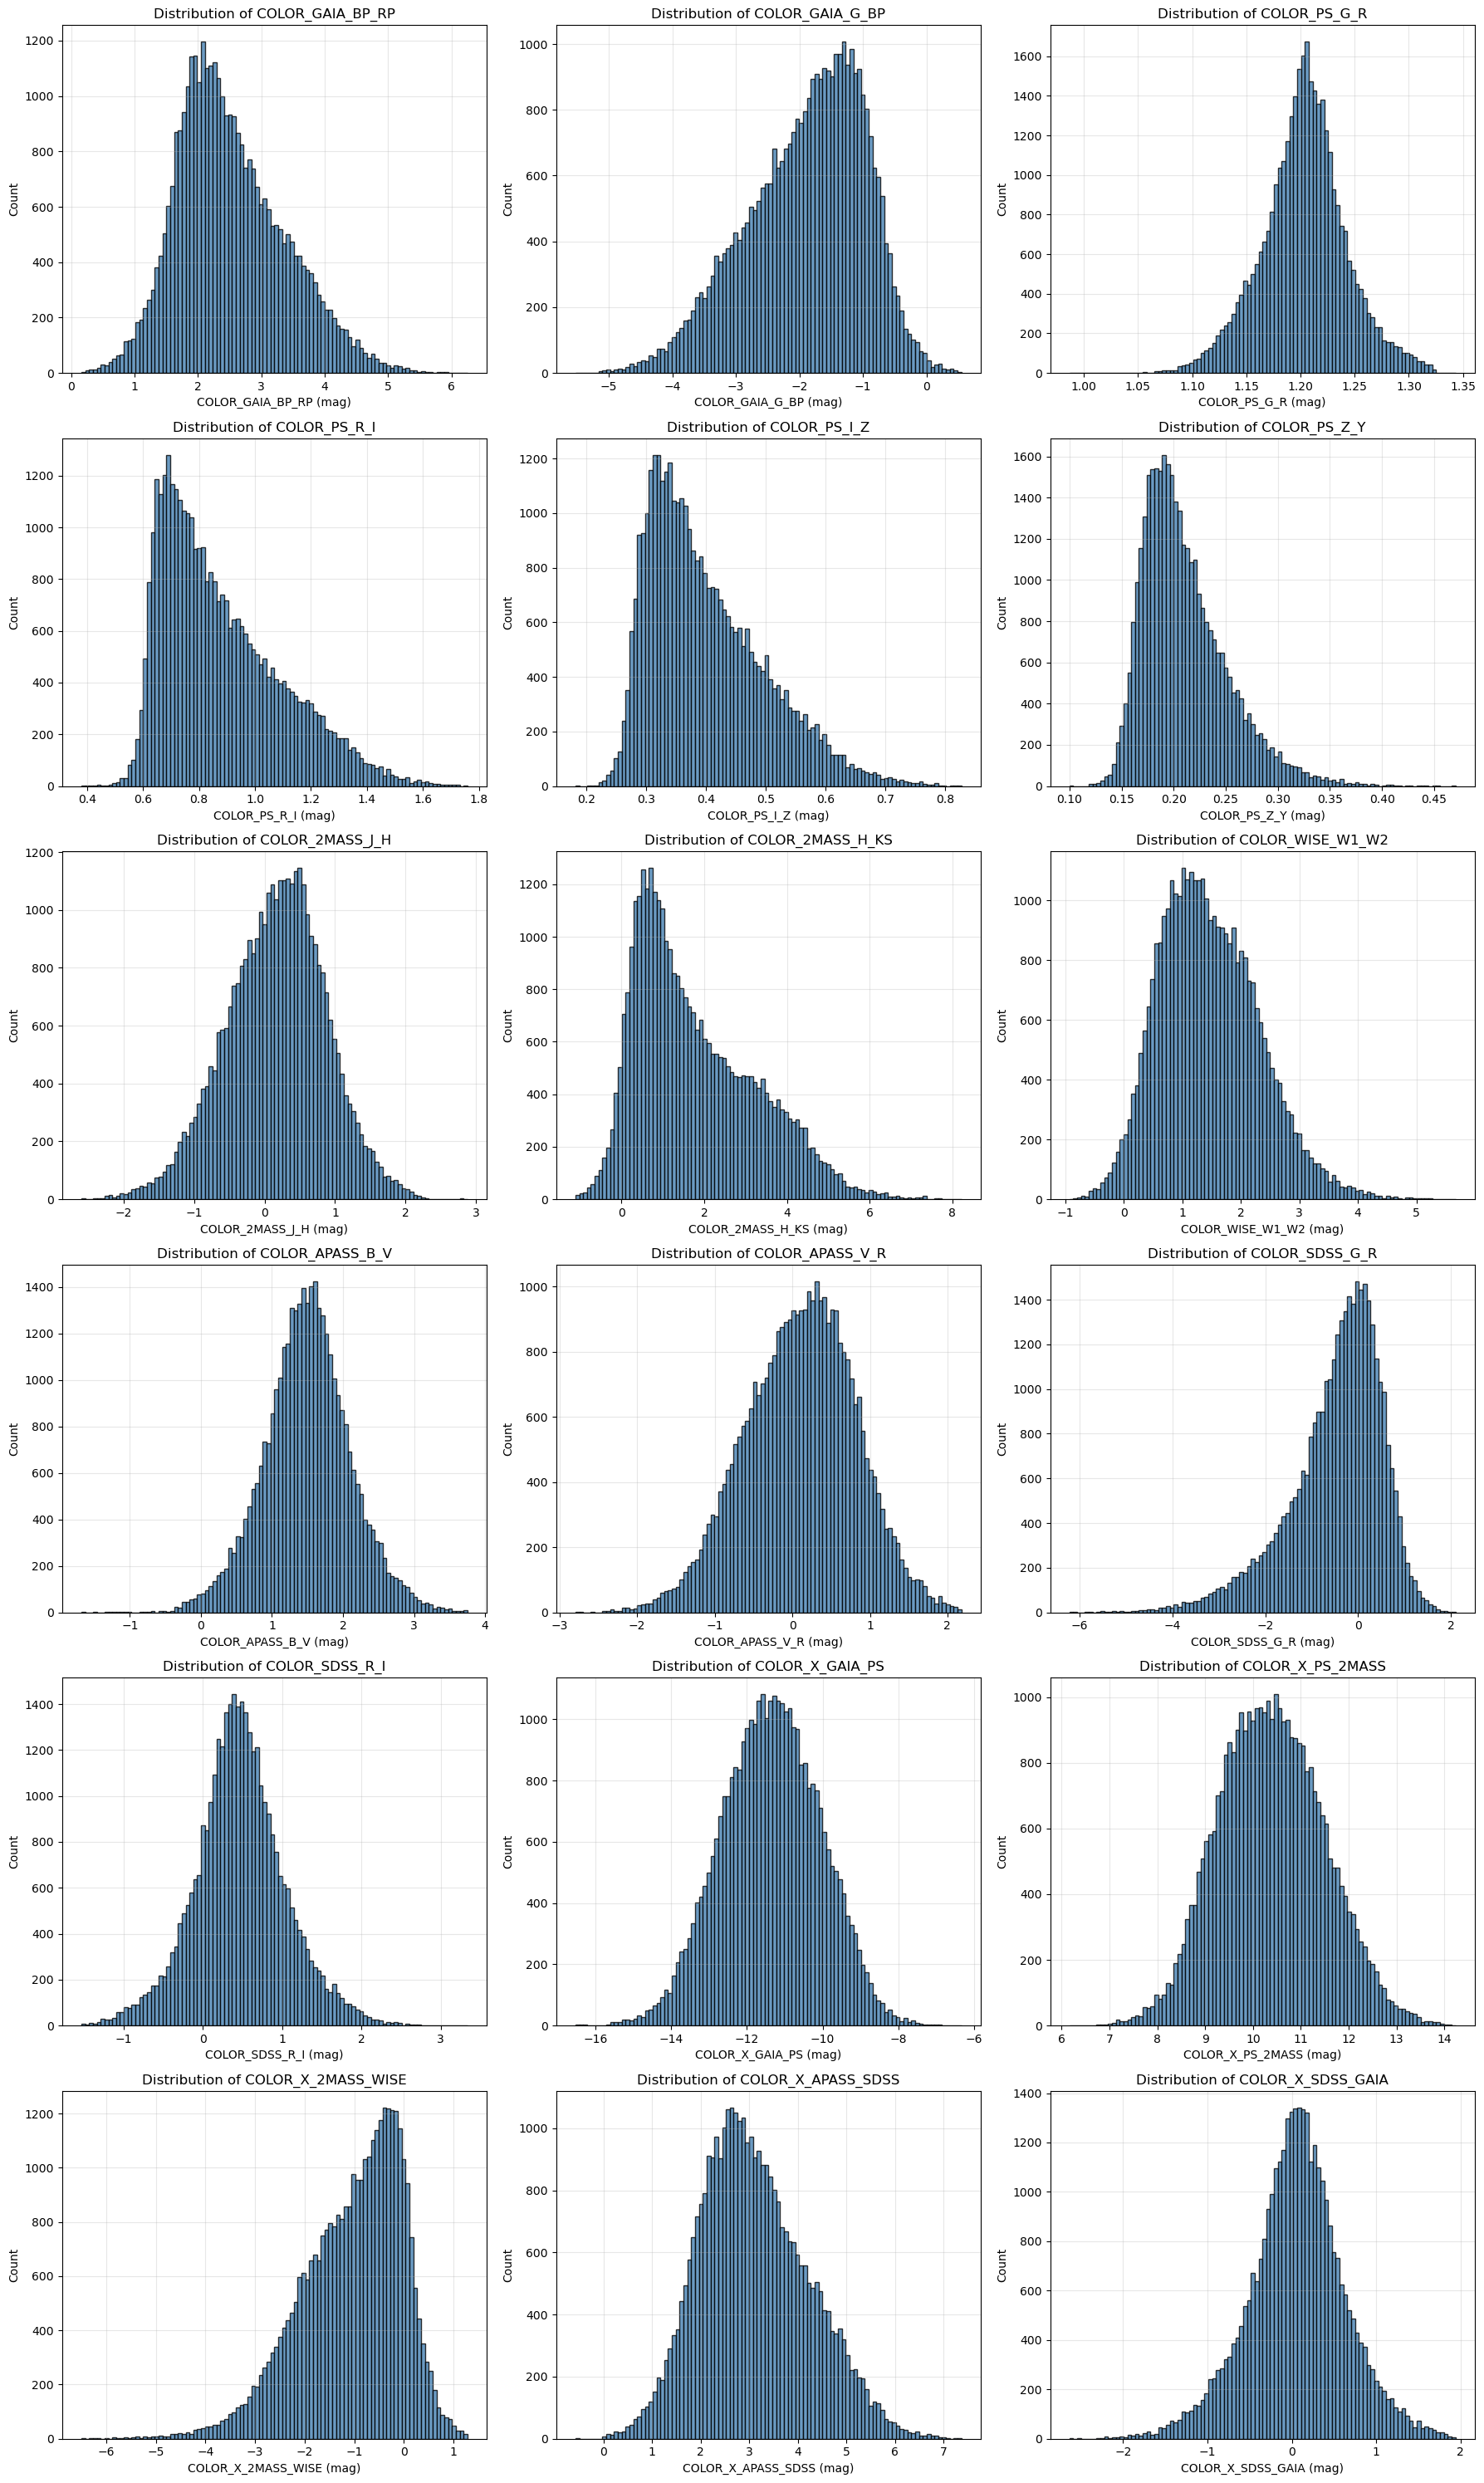

In [ ]:
# 1. Color distribution plots for ALL colors (6x3 grid for 17 colors)
n_colors = len(color_combinations)
n_cols = 3
n_rows = (n_colors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(color_combinations.keys()):
    ax = axes[i]
    df_clean_viz[color_name].plot.hist(bins=100, ax=ax, alpha=0.8, color='steelblue', edgecolor='black')
    ax.set_xlabel(f'{color_name} (mag)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {color_name}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_color_distributions_all.png', dpi=150, bbox_inches='tight')
plt.show()

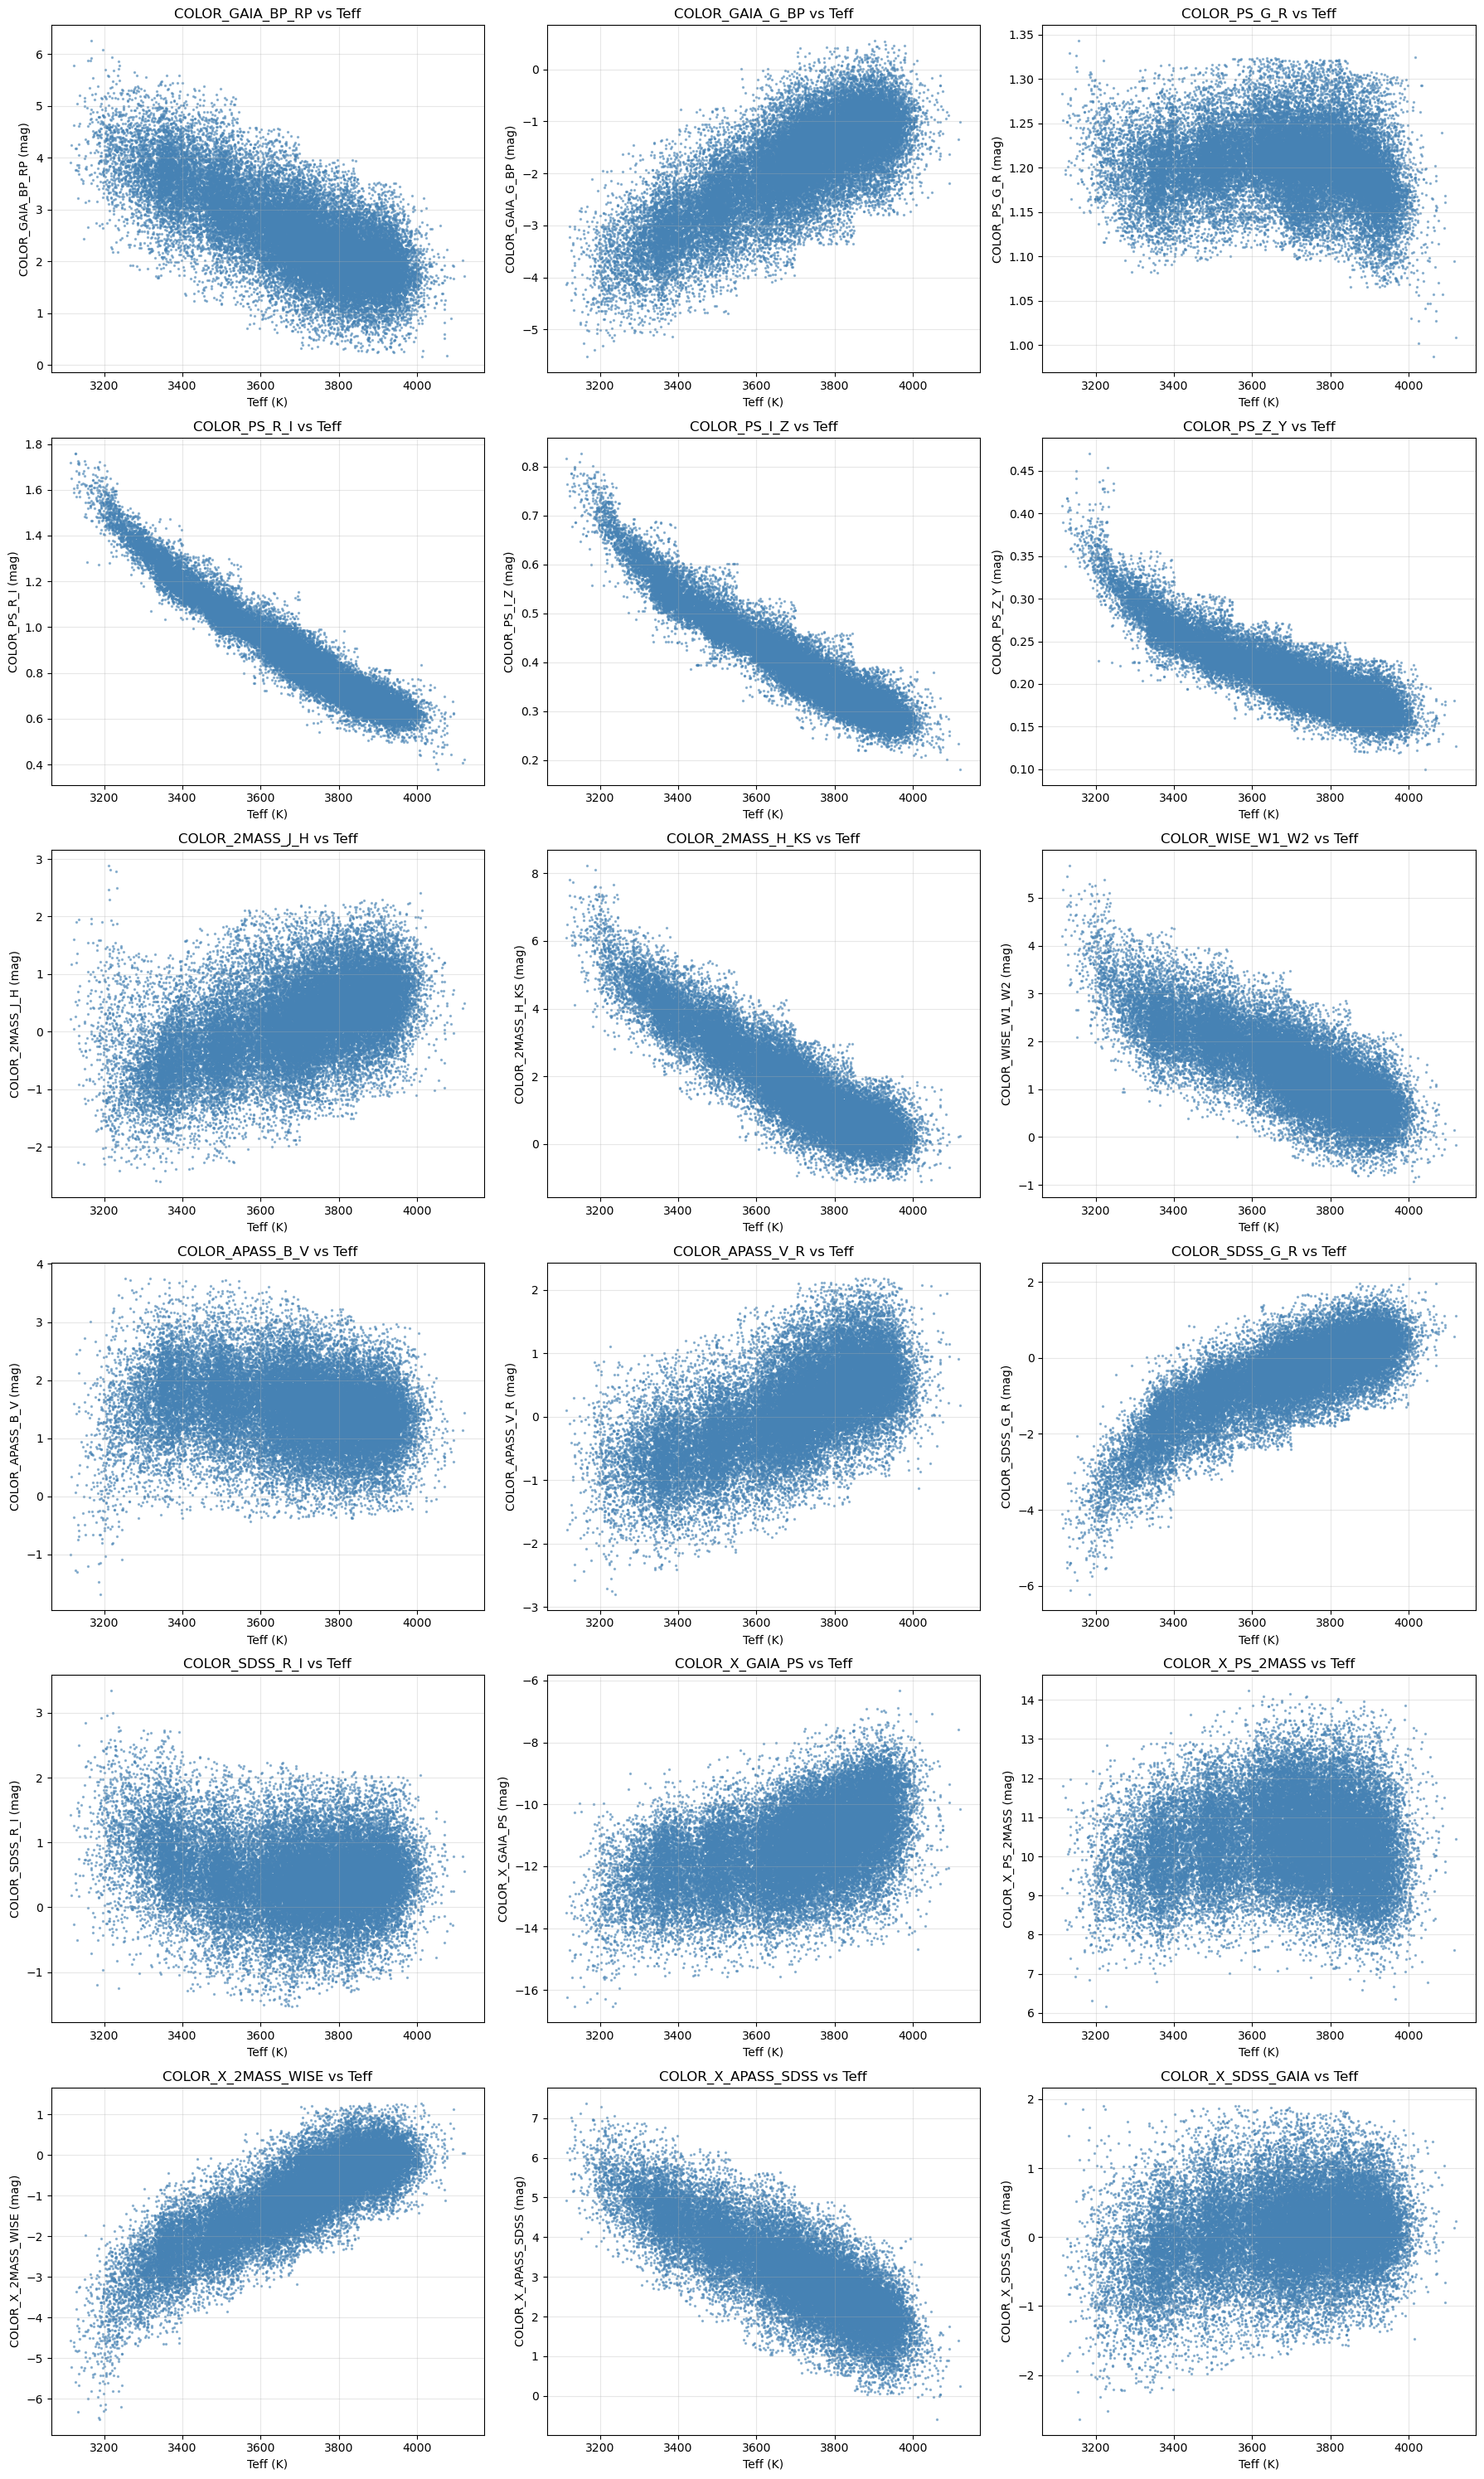

In [ ]:
# 2. ALL color vs Teff plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(color_combinations.keys()):
    ax = axes[i]
    ax.scatter(df_clean_viz['teff'], df_clean_viz[color_name], color='steelblue', alpha=0.5, s=2)
    ax.set_xlabel('Teff (K)')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs Teff')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_teff.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 3. Bin-wise plots for ALL colors
print("Generating bin-wise plots for all colors... this may take a moment.")
teff_bins_available = sorted(df_clean_viz['teff_bin'].dropna().unique())
n_bins = len(teff_bins_available)

for color_name in color_combinations.keys():
    n_rows_bin = (n_bins + 2) // 3
    fig, axes = plt.subplots(n_rows_bin, 3, figsize=(18, 5*n_rows_bin), sharex=True)
    axes = axes.flatten()
    
    for i, bin_name in enumerate(teff_bins_available):
        ax = axes[i]
        data = df_clean_viz[df_clean_viz['teff_bin'] == bin_name][color_name].dropna()
        if len(data) > 0:
            ax.hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            mu, sigma = data.mean(), data.std()
            ax.axvline(mu, color='red', label=f'mu={mu:.3f}')
            ax.axvline(mu+sigma, color='orange', linestyle='--', label=f'sigma={sigma:.3f}')
            ax.axvline(mu-sigma, color='orange', linestyle='--')
            ax.set_title(f'{bin_name} (N={len(data)})')
            ax.legend(fontsize='small')
    
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'Bin-wise distributions for {color_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig(RESULTS_DIR / f'clean_{color_name}_bin_distributions.png', dpi=100)
    plt.close() # Close to save memory
print("Done.")

Generating bin-wise plots for all colors... this may take a moment.
Done.
